### Библиотеки / данные

импортируем библиотеки numpy и pandas

In [1]:
import numpy as np
import pandas as pd

задаем некоторые настройки pandas, регулирующие формат вывода

In [ ]:
pd.options.display.max_rows = 20

### Слияние датафреймов

**Типы соединений**
<img src='https://avatars.dzeninfra.ru/get-zen_doc/5262999/pub_624450910c64d647213cad49_62445249c3c4ec4ac724a341/scale_1200'/>

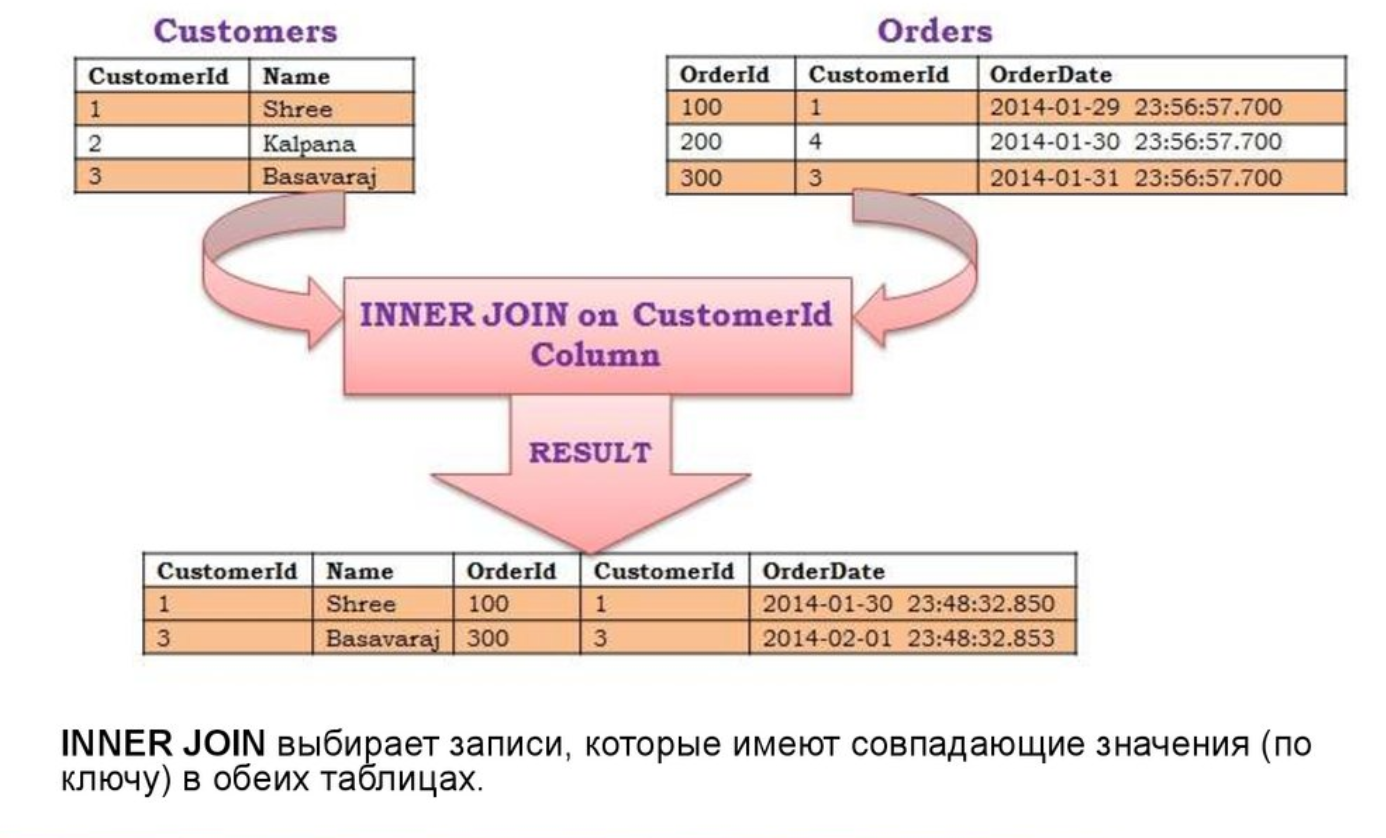

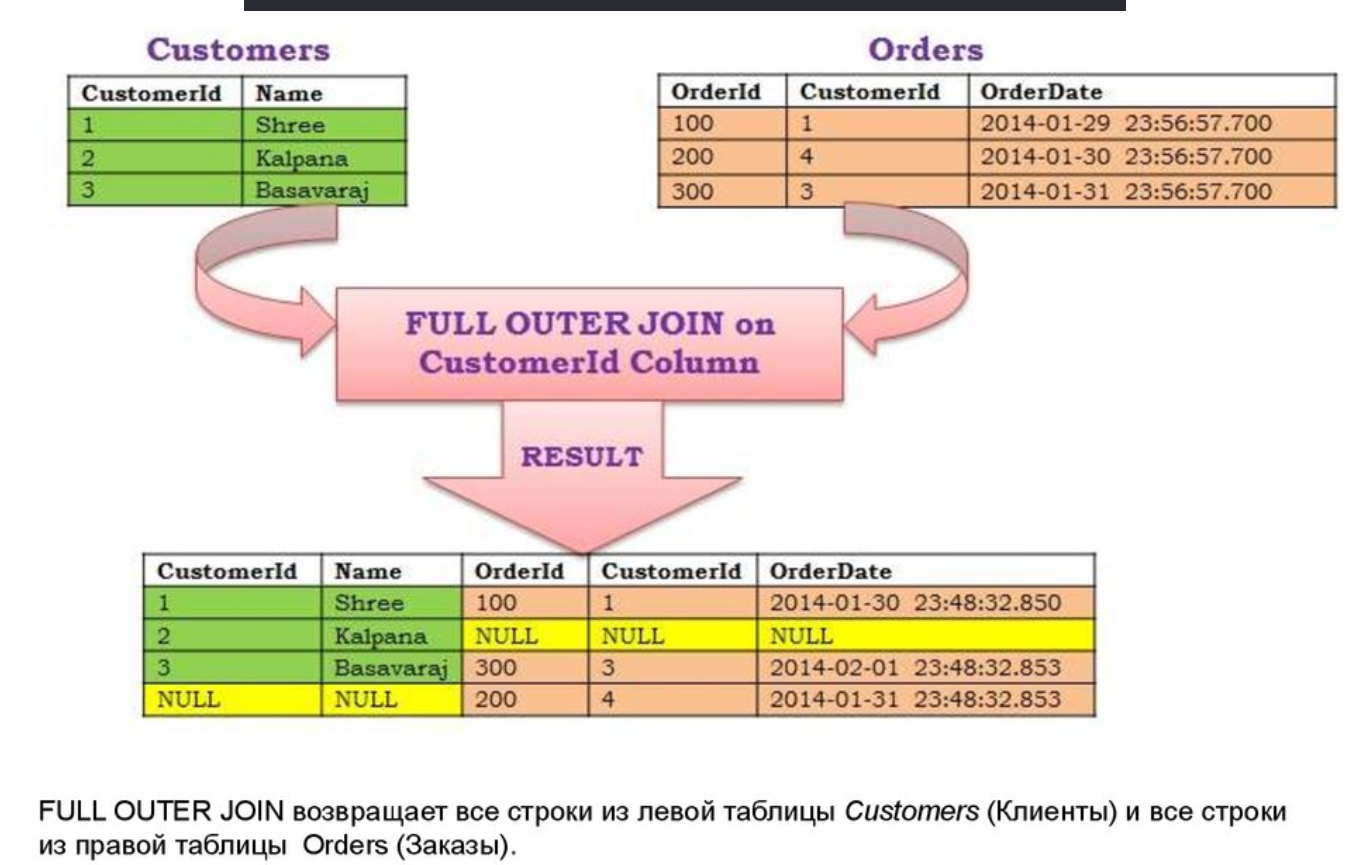

**Аргументы функции merge**


| Аргумент        | Описание
| ------------- |:-------------:|
|left|Объект DataFrame в левой части операции слияния|
|right|Объект DataFrame в правой части операции слияния|
|how|Допустимые значения: 'inner', 'outer', 'left', 'right '|
|on|Имена столбцов, по которым производится соединение. Должны присутствовать в обоих объектах DataFrame. Если не заданы и не указаны никакие другие ключи соединения, то используются имена столбцов, общих для обоих объектов|
|left_on|Столбцы левого DataFrame, используемые как ключи соединения|
|right_on|Столбцы правого DataFrame, используемые как ключи соединения|
|left index|Использовать индекс строк левого DataFrame в качестве его ключа соединения (или нескольких ключей в случае мультииндекса)|
|right_index|То же, что left_index, но для правого DataFrame|
|sort|Сортировать слитые данные лексикографически по ключам соединения по умолчанию True. Иногда при работе с большими наборами данных лучше отключить
|suffixes|Кортеж строк, которые дописываются в конец совпадающих имен столбцов;
|сору|Если равен False, то в некоторых особых случаях разрешается не копировать данные в результирующую структуру.|

для примеров:

In [ ]:
df1 = pd.DataFrame({'key': ['a','a', 'a', 'b', 'b', 'c', 'd'],
                    'data1': range(7)},
                    index = range(3,10))
df2 = pd.DataFrame({'key': ['a', 'b', 'b', 'f'],
                    'data2': range(4)})

In [ ]:
df1

,key,data1
3,a,0
4,a,1
5,a,2
6,b,3
7,b,4
8,c,5
9,d,6


In [ ]:
df2

,key,data2
0,a,0
1,b,1
2,b,2
3,f,3


по умолчанию:

In [ ]:
pd.merge(df1, df2)

,key,data1,data2
0,a,0,0
1,a,1,0
2,a,2,0
3,b,3,1
4,b,3,2
5,b,4,1
6,b,4,2


по каким столбцам соединять?

In [ ]:
pd.merge(df1, df2, on='key')

,key,data1,data2
0,a,0,0
1,a,1,0
2,a,2,0
3,b,3,1
4,b,3,2
5,b,4,1
6,b,4,2


разные имена столбцов:

In [ ]:
pd.merge(df1, df2, left_on='data1', right_on='data2')

,key_x,data1,key_y,data2
0,a,0,a,0
1,a,1,b,1
2,a,2,b,2
3,b,3,f,3


задание суффиксовов:

In [ ]:
pd.merge(df1, df2, left_on='data1', right_on='data2',suffixes=('_left', '_right'))

,key_left,data1,key_right,data2
0,a,0,a,0
1,a,1,b,1
2,a,2,b,2
3,b,3,f,3


соединение по нескольким столбцам:

In [ ]:
pd.merge(df1, df2,
         left_on=['data1', 'key'],
         right_on=['data2', 'key'])

,key,data1,data2
0,a,0,0


указываем тип соединения:

In [ ]:
pd.merge(df1, df2, how='outer')

,key,data1,data2
0,a,0.0,0.0
1,a,1.0,0.0
2,a,2.0,0.0
3,b,3.0,1.0
4,b,3.0,2.0
5,b,4.0,1.0
6,b,4.0,2.0
7,c,5.0,NaN
8,d,6.0,NaN
9,f,NaN,3.0


In [ ]:
df1

,key,data1
3,a,0
4,a,1
5,a,2
6,b,3
7,b,4
8,c,5
9,d,6


In [ ]:
df2

,key,data2
0,a,0
1,b,1
2,b,2
3,f,3


In [ ]:
pd.merge(df1, df2, left_index=True, right_on='data2')

,key_x,data1,key_y,data2
3,a,0,f,3


In [ ]:
pd.merge(df1, df2, left_on='data1', right_index=True)

,key_x,data1,key_y,data2
3,a,0,a,0
4,a,1,b,1
5,a,2,b,2
6,b,3,f,3


In [ ]:
pd.merge(df1, df2, left_index=True, right_index=True)

,key_x,data1,key_y,data2
3,a,0,f,3


### Конкатенация датафреймов

для примеров:

In [ ]:
df1 = pd.DataFrame(index = range(3), data = np.arange(9).reshape(3, 3),
                   columns=['a', 'b', 'c'])
df2 = pd.DataFrame(index = range(2,5), data = np.arange(9, 18).reshape(3, 3),
                   columns=['a', 'c', 'd'])

In [ ]:
df1

,a,b,c
0,0,1,2
1,3,4,5
2,6,7,8


In [ ]:
df2

,a,c,d
2,9,10,11
3,12,13,14
4,15,16,17


По умолчанию:

In [ ]:
pd.concat([df1, df2], sort=True)

,a,b,c,d
0,0,1.0,2,NaN
1,3,4.0,5,NaN
2,6,7.0,8,NaN
2,9,NaN,10,11.0
3,12,NaN,13,14.0
4,15,NaN,16,17.0


In [ ]:
pd.concat([df1, df2], axis=0, sort=True, join='inner')

,a,c
0,0,2
1,3,5
2,6,8
2,9,10
3,12,13
4,15,16


По оси столбцов:

In [ ]:
pd.concat([df1, df2], axis=1, sort=True)

,a,b,c,a,c,d
0,0.0,1.0,2.0,NaN,NaN,NaN
1,3.0,4.0,5.0,NaN,NaN,NaN
2,6.0,7.0,8.0,9.0,10.0,11.0
3,NaN,NaN,NaN,12.0,13.0,14.0
4,NaN,NaN,NaN,15.0,16.0,17.0


In [ ]:
df1

,a,b,c
0,0,1,2
1,3,4,5
2,6,7,8


In [ ]:
df2

,a,c,d
2,9,10,11
3,12,13,14
4,15,16,17


### "Long” и “Wide”

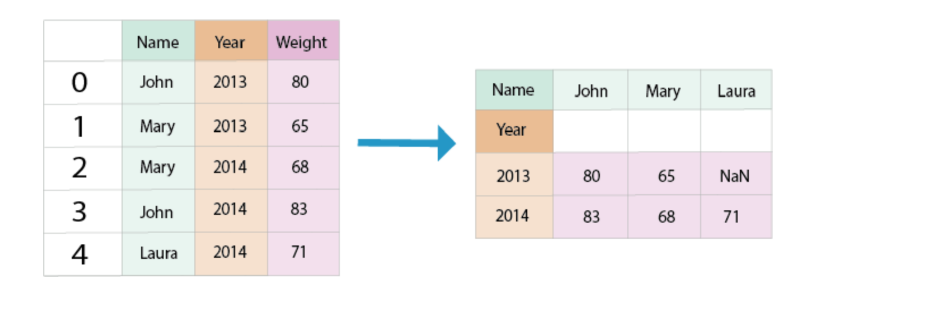

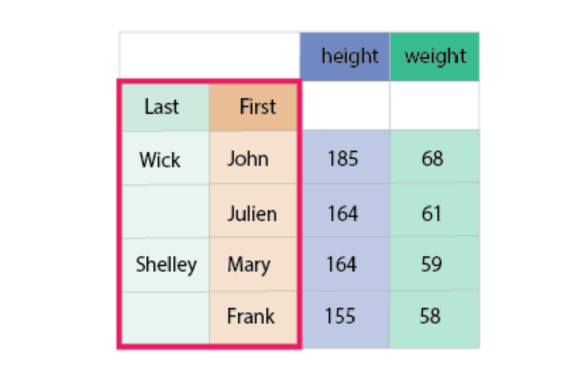

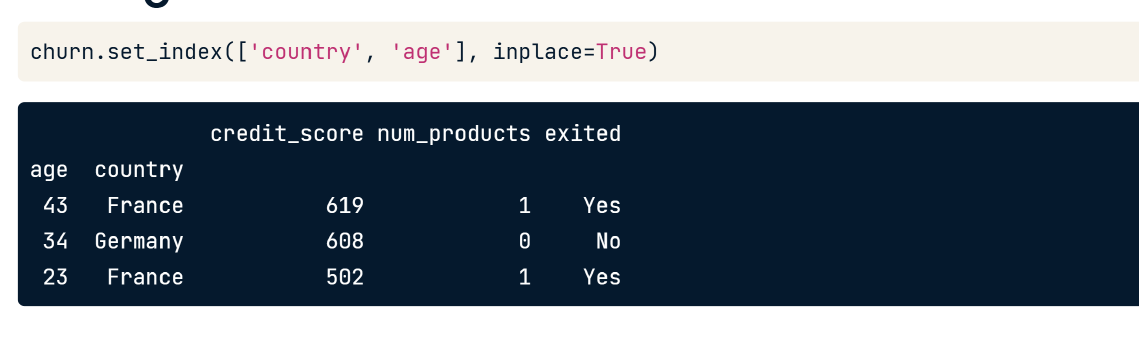

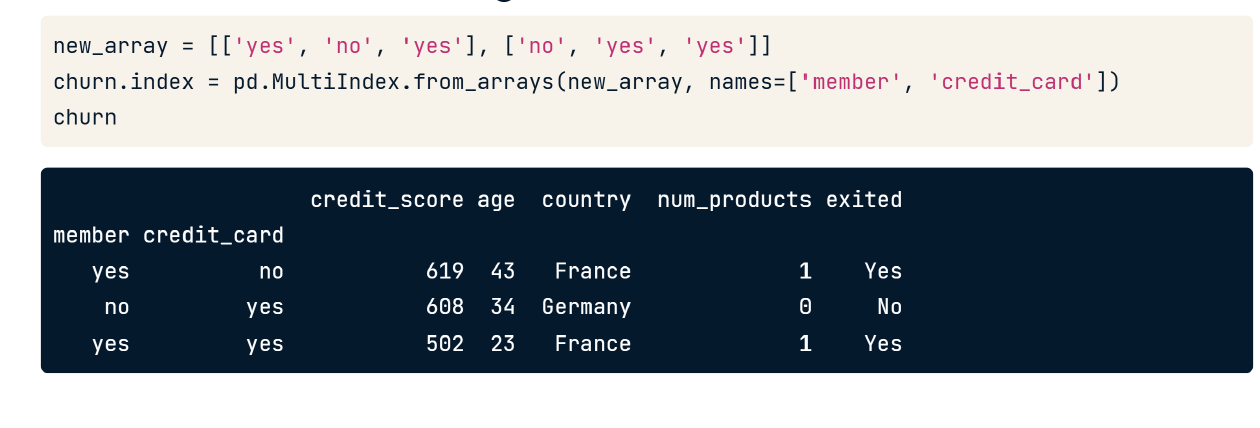

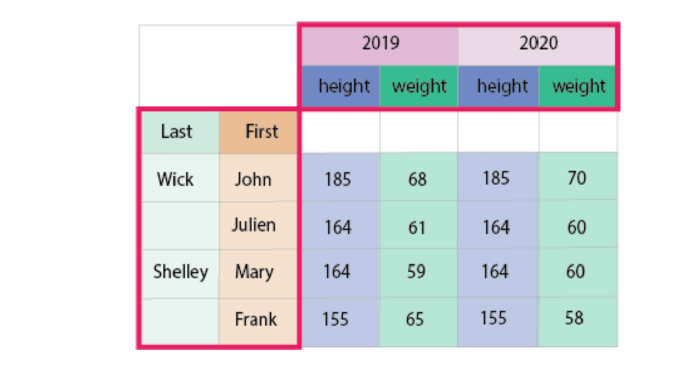

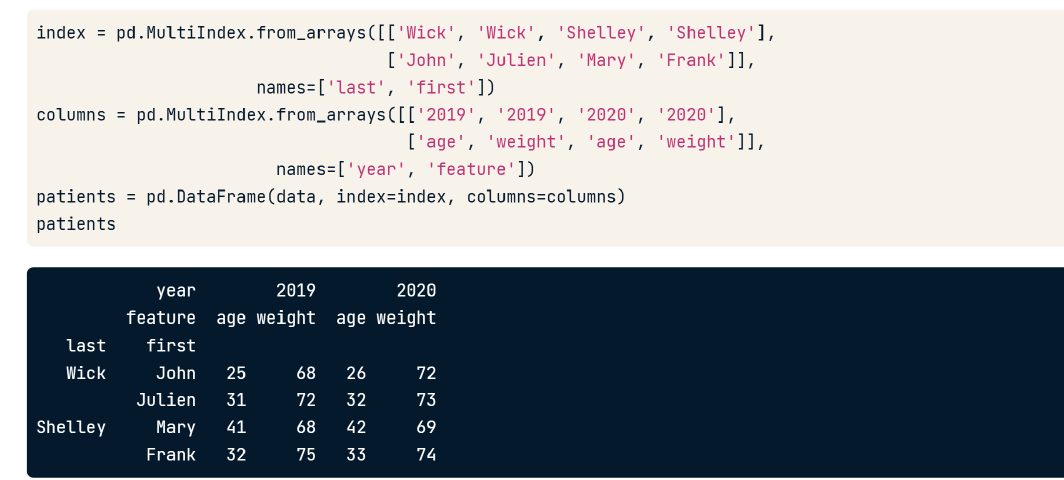

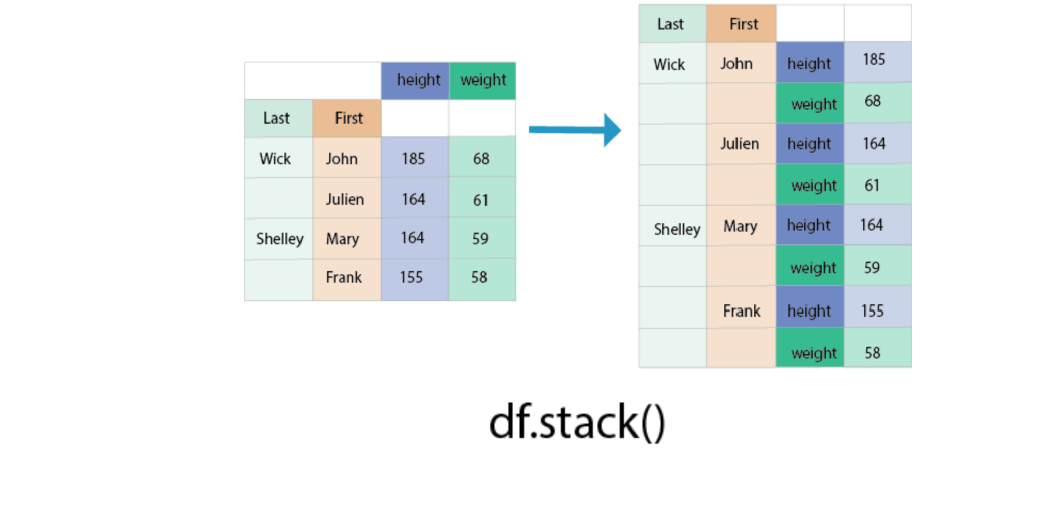

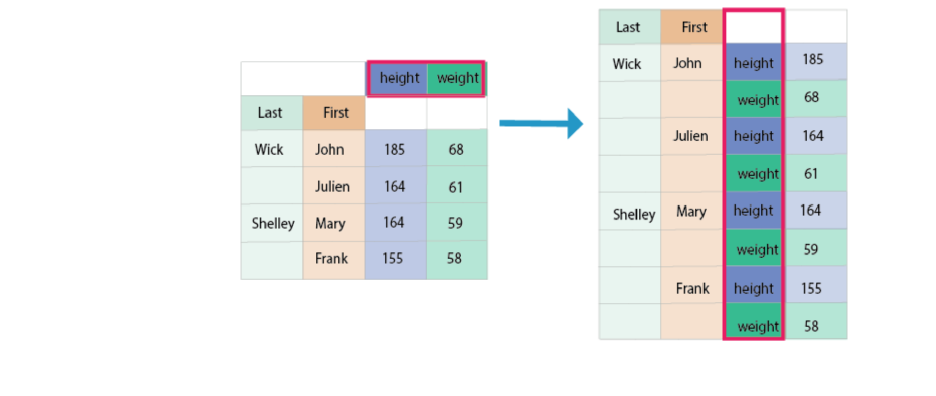

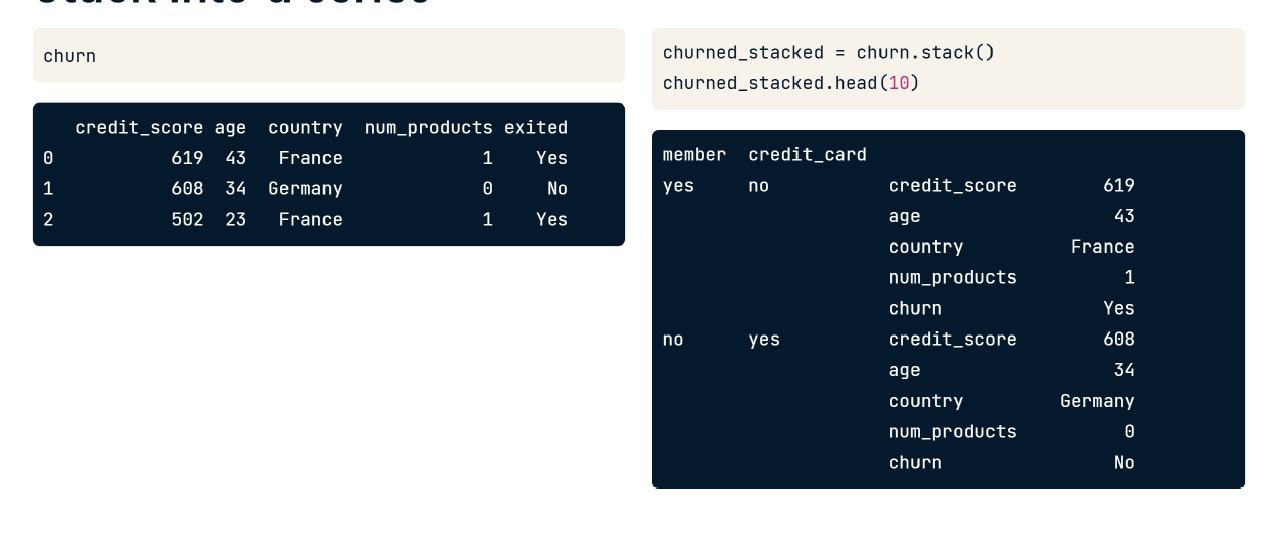

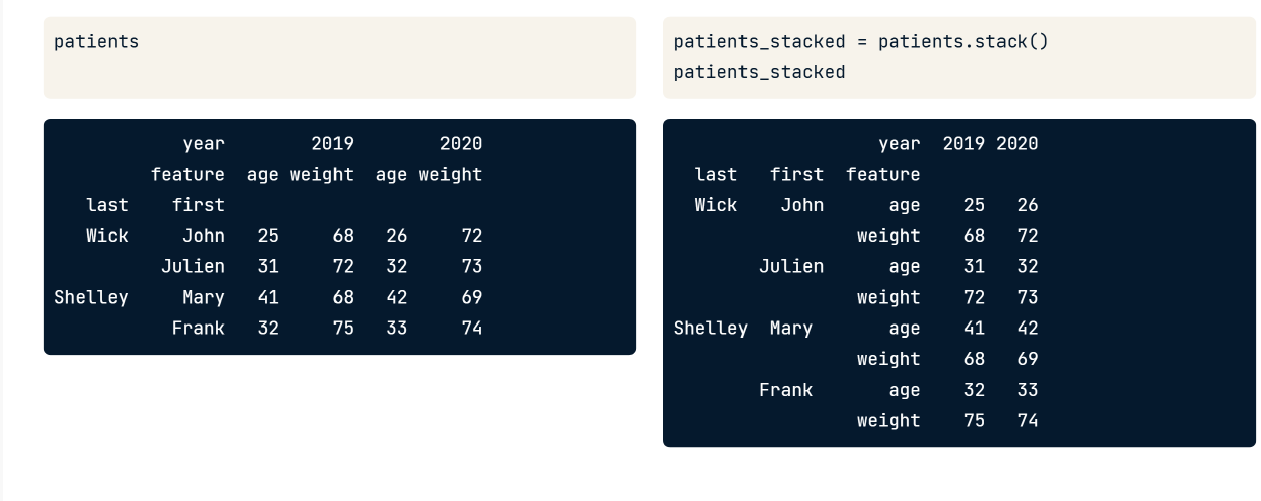

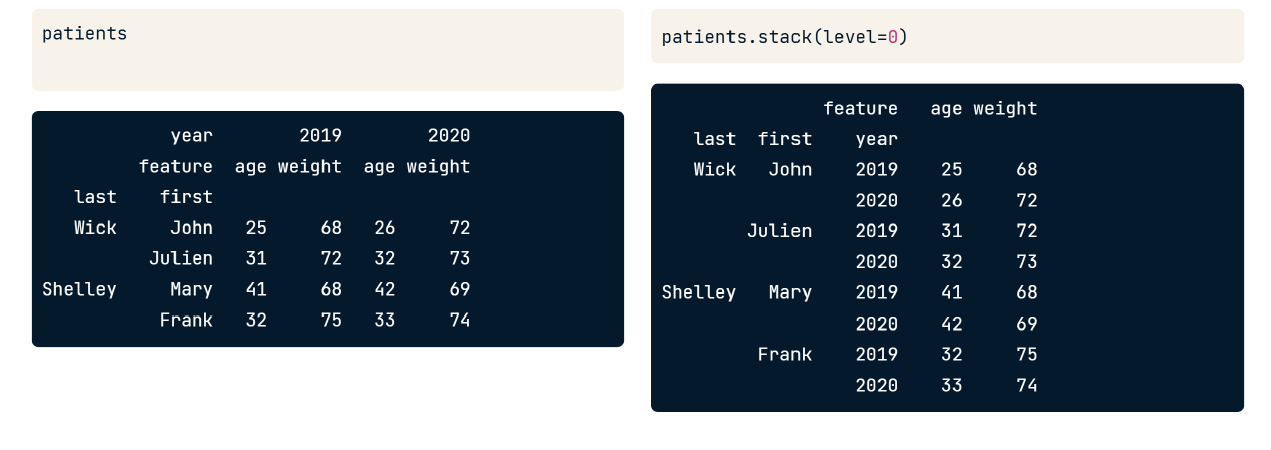

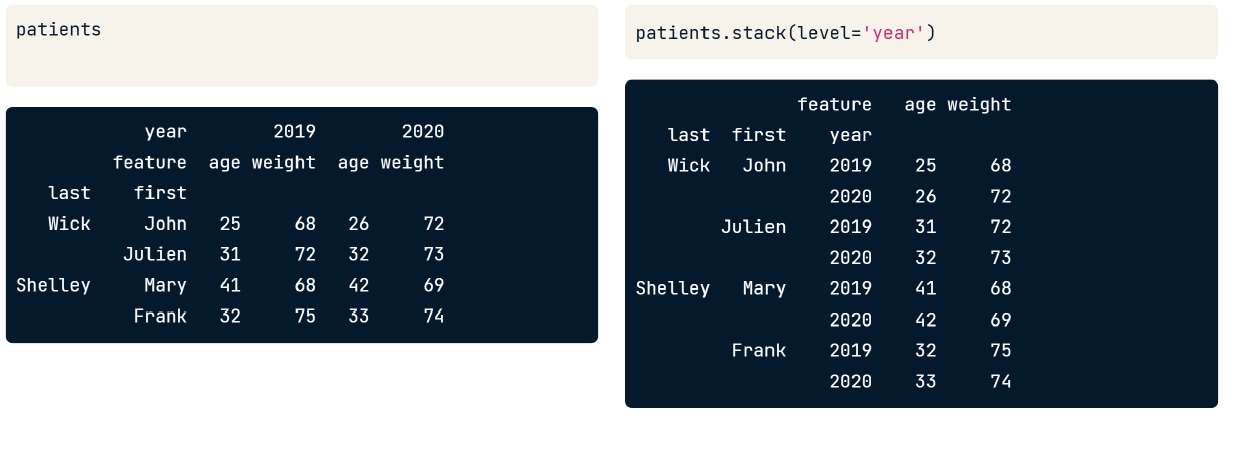

считываем данные акселерометра ("Long")

In [ ]:
long_format = pd.read_csv("https://raw.githubusercontent.com/trisha00001/file/main/accel.csv")
long_format

,interval,axis,reading
0,0,X,0.0
1,0,Y,0.5
2,0,Z,1.0
3,1,X,0.1
4,1,Y,0.4
5,1,Z,0.9
6,2,X,0.2
7,2,Y,0.3
8,2,Z,0.8
9,3,X,0.3


"Wide" формат, используем unstack:

In [ ]:
tmp = long_format.set_index(['interval','axis'])
tmp

reading
interval axis         
0        X         0.0
         Y         0.5
         Z         1.0
1        X         0.1
         Y         0.4
         Z         0.9
2        X         0.2
         Y         0.3
         Z         0.8
3        X         0.3
         Y         0.2
         Z         0.7

In [ ]:
tmp = tmp.unstack()
tmp

reading          
axis           X    Y    Z
interval                  
0            0.0  0.5  1.0
1            0.1  0.4  0.9
2            0.2  0.3  0.8
3            0.3  0.2  0.7

"Wide" формат, используем pivot:

In [ ]:
wide_format = long_format.pivot(index='interval',
                                columns='axis',
                                values='reading')

wide_format

axis,X,Y,Z
interval,,,
0,0.0,0.5,1.0
1,0.1,0.4,0.9
2,0.2,0.3,0.8
3,0.3,0.2,0.7


Из "Wide" в "Long" формат:

In [ ]:
long_format_stack = wide_format.stack()
long_format_stack

interval  axis
0         X       0.0
          Y       0.5
          Z       1.0
1         X       0.1
          Y       0.4
          Z       0.9
2         X       0.2
          Y       0.3
          Z       0.8
3         X       0.3
          Y       0.2
          Z       0.7
dtype: float64

создаем две копии данных акселерометра, по одной для каждого пользователя

In [ ]:
user1 = long_format.copy()
user2 = long_format.copy()

добавляем столбец who в каждую копию

In [ ]:
user1['who'] = 'Mike'
user2['who'] = 'David'

отмасштабируем данные user2

In [ ]:
user2['reading'] *= 100

In [ ]:
user1

,interval,axis,reading,who
0,0,X,0.0,Mike
1,0,Y,0.5,Mike
2,0,Z,1.0,Mike
3,1,X,0.1,Mike
4,1,Y,0.4,Mike
5,1,Z,0.9,Mike
6,2,X,0.2,Mike
7,2,Y,0.3,Mike
8,2,Z,0.8,Mike
9,3,X,0.3,Mike


In [ ]:
user2

,interval,axis,reading,who
0,0,X,0.0,David
1,0,Y,50.0,David
2,0,Z,100.0,David
3,1,X,10.0,David
4,1,Y,40.0,David
5,1,Z,90.0,David
6,2,X,20.0,David
7,2,Y,30.0,David
8,2,Z,80.0,David
9,3,X,30.0,David


организуем данные так, чтобы получить иерархический индекс строк

In [ ]:
multi_user_long_format = pd.concat([user1, user2]).set_index(['who', 'interval', 'axis'])
multi_user_long_format

reading
who   interval axis         
Mike  0        X         0.0
               Y         0.5
               Z         1.0
      1        X         0.1
               Y         0.4
...                      ...
David 2        Y        30.0
               Z        80.0
      3        X        30.0
               Y        20.0
               Z        70.0

[24 rows x 1 columns]

пример для повторения извлекаем все показания по всем осям и по всем пользователям при interval == 1

In [ ]:
multi_user_long_format.xs(1, level='interval')

reading
who   axis         
Mike  X         0.1
      Y         0.4
      Z         0.9
David X        10.0
      Y        40.0
      Z        90.0

выполняем расстыковку, в результате 2-й уровень индекса строк (уровень axis) стал уровнем индекса столбцов

In [ ]:
multi_user_wide_format = multi_user_long_format.unstack()
multi_user_wide_format

reading             
axis                 X     Y      Z
who   interval                     
David 0            0.0  50.0  100.0
      1           10.0  40.0   90.0
      2           20.0  30.0   80.0
      3           30.0  20.0   70.0
Mike  0            0.0   0.5    1.0
      1            0.1   0.4    0.9
      2            0.2   0.3    0.8
      3            0.3   0.2    0.7

параметр level:

In [ ]:
multi_user_long_format.unstack(level = 1)

reading                  
interval         0     1     2     3
who   axis                          
David X        0.0  10.0  20.0  30.0
      Y       50.0  40.0  30.0  20.0
      Z      100.0  90.0  80.0  70.0
Mike  X        0.0   0.1   0.2   0.3
      Y        0.5   0.4   0.3   0.2
      Z        1.0   0.9   0.8   0.7

In [ ]:
import pandas as pd
df = pd.read_excel('https://github.com/datagy/mediumdata/raw/master/sample_pivot.xlsx', parse_dates=['Date'])
print(df.head())

        Date Region                 Type  Units  Sales
0 2020-07-11   East  Children's Clothing   18.0    306
1 2020-09-23  North  Children's Clothing   14.0    448
2 2020-04-02  South     Women's Clothing   17.0    425
3 2020-02-28   East  Children's Clothing   26.0    832
4 2020-03-19   West     Women's Clothing    3.0     33


In [ ]:
pivot = pd.pivot_table(
    data=df,
    values= ['Units','Sales'],
    index='Region'
)
print(pivot)

             Sales      Units
Region                       
East    408.182482  19.732360
North   438.924051  19.202643
South   432.956204  20.423358
West    452.029412  19.294118


In [ ]:
pivot = pd.pivot_table(
    data=df,
    index='Region',
    values='Sales'
)
pivot

,Sales
Region,
East,408.182482
North,438.924051
South,432.956204
West,452.029412


In [ ]:
pivot = pd.pivot_table(
    data=df,
    index='Region',
    aggfunc='sum'
)

In [ ]:
pivot = pd.pivot_table(
    data=df,
    index='Region',
    columns='Type',
    values='Sales',
    margins=True
)

print(pivot)


Type    Children's Clothing  Men's Clothing  Women's Clothing         All
Region                                                                   
East             405.743363      423.647541        399.028409  408.182482
North            438.894118      449.157303        432.528169  438.924051
South            412.666667      475.435897        418.924528  432.956204
West             480.523810      465.292683        419.188679  452.029412
All              427.743860      444.257732        415.254717  427.254000


In [ ]:
(405+424+399)/3

409.3333333333333

In [ ]:
pivot = pd.pivot_table(
    data=df,
    index='Region', values=['Sales', 'Units']
)
print(pivot)


             Sales      Units
Region                       
East    408.182482  19.732360
North   438.924051  19.202643
South   432.956204  20.423358
West    452.029412  19.294118


In [ ]:
# Specifying the Aggregation Function
pivot = pd.pivot_table(
    data=df,
    index='Region',
    values=['Sales', 'Units'],
    aggfunc='sum'
)

print(pivot)

         Sales   Units
Region                
East    167763  8110.0
North   138700  4359.0
South    59315  2798.0
West     61476  2624.0
